In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import morphology, measure, exposure
from skimage.filters import gaussian, frangi, apply_hysteresis_threshold
from skimage.morphology import remove_small_objects, binary_closing, disk, binary_dilation
from skimage.measure import label, regionprops
import os
import imageio
import numpy as np
from skimage import exposure, filters, morphology, feature
from skimage.filters import frangi
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import binary_dilation, disk

In [2]:
# Utils
def to_float01(x):
    x = x.astype(np.float32)
    if x.max() > 1.0:
        x /= 255.0
    return np.clip(x, 0, 1)

def imread_rgb(path: str) -> np.ndarray:
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


# FOV + scaling
def compute_fov_and_radius(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    _, m = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    m = m.astype(bool)

    lab = measure.label(m)
    if lab.max() == 0:
        fov = np.ones(gray.shape, dtype=bool)
    else:
        regions = measure.regionprops(lab)
        largest = max(regions, key=lambda r: r.area)
        fov = (lab == largest.label)

    area = float(np.sum(fov))
    radius = np.sqrt(area / np.pi)
    return fov, radius

def inner_fov_mask(fov, radius):
    band = int(max(20, radius * 0.06))
    return morphology.binary_erosion(fov, disk(band))

def show_all(rgb, I, V, BH, C, boundary_band, seed, loose, mask, final_mask, fov_in):
    plt.figure(figsize=(22, 10))

    plt.subplot(2,6,1); plt.imshow(rgb); plt.title("Original RGB"); plt.axis("off")
    plt.subplot(2,6,2); plt.imshow(I, cmap="gray"); plt.title("Preprocessed I"); plt.axis("off")
    plt.subplot(2,6,3); plt.imshow(V, cmap="gray"); plt.title("Frangi V"); plt.axis("off")
    plt.subplot(2,6,4); plt.imshow(BH, cmap="gray"); plt.title("Blackhat BH"); plt.axis("off")
    plt.subplot(2,6,5); plt.imshow(C, cmap="gray"); plt.title("Combined C"); plt.axis("off")
    plt.subplot(2,6,6); plt.imshow(boundary_band, cmap="gray"); plt.title("Boundary band"); plt.axis("off")

    plt.subplot(2,6,7); plt.imshow(fov_in, cmap="gray"); plt.title("FOV_in"); plt.axis("off")
    plt.subplot(2,6,8); plt.imshow(seed, cmap="gray"); plt.title("Seed"); plt.axis("off")
    plt.subplot(2,6,9); plt.imshow(loose, cmap="gray"); plt.title("Loose (hysteresis)"); plt.axis("off")
    plt.subplot(2,6,10); plt.imshow(mask, cmap="gray"); plt.title("Mask (connected-to-seed)"); plt.axis("off")
    plt.subplot(2,6,11); plt.imshow(final_mask, cmap="gray"); plt.title("Final mask"); plt.axis("off")

    # differences
    only_loose = loose & (~mask)
    plt.subplot(2,6,12); plt.imshow(only_loose, cmap="gray"); plt.title("Loose \\ Mask"); plt.axis("off")

    plt.tight_layout()
    plt.show()



# Preprocess
def preprocess_green(rgb, fov_in, radius):
    g = to_float01(rgb[..., 1])
    g2 = g.copy()
    g2[~fov_in] = np.median(g[fov_in])

    # robust normalize inside fov
    p1, p99 = np.percentile(g2[fov_in], [1, 99])
    g2 = np.clip((g2 - p1) / (p99 - p1 + 1e-8), 0, 1)

    # CLAHE
    ks = int(max(32, radius * 0.20))
    g_eq = exposure.equalize_adapthist(g2, kernel_size=ks, clip_limit=0.02)

    # illumination correction
    sigma_bg = max(10.0, 0.04 * radius)
    bg = gaussian(g_eq, sigma=sigma_bg)
    I = g_eq - bg
    I = (I - np.min(I[fov_in])) / (np.ptp(I[fov_in]) + 1e-8)
    I[~fov_in] = 0.0
    return I

def normalize_in_fov(X, fov_in):
    vals = X[fov_in]
    lo, hi = np.percentile(vals, [1, 99.5])
    Y = (X - lo) / (hi - lo + 1e-8)
    Y = np.clip(Y, 0, 1)
    Y[~fov_in] = 0
    return Y


# Vesselness: Frangi + Blackhat
def vessel_enhance_blackhat(corr, fov_in, radius):
    img_u8 = (corr * 255).astype(np.uint8)

    ks = [
        int(max(9,  radius * 0.015)),
        int(max(15, radius * 0.025)),
    ]
    ks = [k + 1 if k % 2 == 0 else k for k in ks]

    acc = np.zeros_like(corr, dtype=np.float32)
    for k in ks:
        se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        bh = cv2.morphologyEx(img_u8, cv2.MORPH_BLACKHAT, se).astype(np.float32) / 255.0
        acc = np.maximum(acc, bh)

    acc[~fov_in] = 0.0

    vals = acc[fov_in]
    p2, p999 = np.percentile(vals, [2, 99.9])
    acc = (acc - p2) / (p999 - p2 + 1e-8)
    acc = np.clip(acc, 0, 1)
    return acc**0.7

def combined_vesselness(I, fov_in, radius):
    max_sigma = int(min(10, max(3, radius * 0.03)))
    V = frangi(1 - I, sigmas=range(1, max_sigma + 1))
    V = np.nan_to_num(V)
    V = normalize_in_fov(V, fov_in)

    BH = vessel_enhance_blackhat(I, fov_in, radius)
    BH = normalize_in_fov(BH, fov_in)

    C = np.maximum(V, BH)
    return V, BH, C


# Connected hysteresis segmentation (auto-ish)
def auto_hysteresis_connected(
    C, fov_in,
    seed_p=99,          # was 95  (stricter seeds)
    high_p=98.0,
    low_candidates=(72, 70, 68, 66),
    frac_range=(0.12, 0.25),
    seed_dilate=0       
):
    vals = C[fov_in]

    thr_seed = np.percentile(vals, seed_p)
    seed = (C >= thr_seed) & fov_in
    seed = remove_small_objects(seed, 30)

    high = np.percentile(vals, high_p)

    best = None
    for low_p in low_candidates:
        low = np.percentile(vals, low_p)
        loose = apply_hysteresis_threshold(C, low, high) & fov_in
        loose = remove_small_objects(loose, 50)
        loose = binary_closing(loose, disk(1))

        lab = label(loose)

        # connectivity selection:
        if seed_dilate > 0:
            seed_touch = binary_dilation(seed, disk(seed_dilate))
        else:
            seed_touch = seed

        keep = np.unique(lab[seed_touch])
        keep = keep[keep != 0]
        mask = np.isin(lab, keep) & fov_in

        frac = mask[fov_in].mean()
        ok = (frac_range[0] <= frac <= frac_range[1])
        score = 0 if ok else min(abs(frac - frac_range[0]), abs(frac - frac_range[1]))

        if best is None or score < best[0]:
            best = (score, low_p, seed, loose, mask, frac)

    _, chosen_low_p, seed, loose, mask, frac = best
    return seed, loose, mask, chosen_low_p, frac

def light_cleanup(mask, fov_in):
    fov_area = float(np.sum(fov_in))
    min_obj = int(max(20, 0.000003 * fov_area))  # slightly gentler
    mask = remove_small_objects(mask & fov_in, min_size=min_obj)
    return mask

# Boundary ring suppression
def suppress_boundary_ring(C, fov, radius):
    band_w = int(max(20, 0.12 * radius))
    inner = morphology.binary_erosion(fov, disk(band_w))
    boundary_band = fov & (~inner)
    boundary_band = morphology.binary_dilation(boundary_band, disk(3))

    C2 = C.copy()
    C2[boundary_band] = 0.0
    return C2, boundary_band


# Contrast-guided attach (keeps vessels from breaking near periphery)
def contrast_guided_attach(I, C, vessel_map, fov_in, thr=0.2, vessel_p=90):
    local_std = gaussian((I - gaussian(I, 5))**2, 3)**0.5
    vals = local_std[fov_in]
    local_std = (local_std - np.percentile(vals, 5)) / (
        np.percentile(vals, 95) - np.percentile(vals, 5) + 1e-8
    )
    local_std = np.clip(local_std, 0, 1)

    ring = morphology.binary_dilation(vessel_map, disk(1)) & (~vessel_map)
    thr_v = np.percentile(C[fov_in], vessel_p)
    cand = ring & (local_std > thr) & (C > thr_v) & fov_in
    return vessel_map | cand

def vessel_prob_map(gray, fov):
    # work only in FOV
    g = gray.astype(np.float32)
    g = (g - np.percentile(g[fov], 1)) / (np.percentile(g[fov], 99) - np.percentile(g[fov], 1) + 1e-8)
    g = np.clip(g, 0, 1)

    # local contrast (helps tiny vessels)
    g = exposure.equalize_adapthist(g, clip_limit=0.01)

    # Frangi vesselness (try these ranges!)
    V = frangi(g, sigmas=np.arange(1, 5, 1), alpha=0.5, beta=0.5, gamma=15)
    V[~fov] = 0
    V = (V - V.min()) / (V.max() - V.min() + 1e-8)
    return V

def hysteresis_segment(V, fov, hi=0.25, lo=0.10):
    # “sure” vessels
    seeds = V > hi
    # “possible” vessels
    candidates = V > lo

    # keep only candidates connected to seeds
    mask = morphology.reconstruction(
        seeds.astype(np.uint8),
        candidates.astype(np.uint8),
        method="dilation"
    ).astype(bool)

    mask &= fov
    return mask

def split_thick(mask):
    # distance inside vessels
    dist = ndi.distance_transform_edt(mask)

    # markers at local maxima (centers of vessels)
    peaks = feature.peak_local_max(dist, footprint=np.ones((7,7)), labels=mask)
    markers = np.zeros_like(mask, dtype=np.int32)
    for i, (r,c) in enumerate(peaks, start=1):
        markers[r,c] = i

    labels = watershed(-dist, markers, mask=mask)

    # merge back to binary but now separated shapes (helps skeleton later)
    return labels > 0

def show_pipeline(rgb, I, V, mask, mask_split, mask_final, fov_in):
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    axes = axes.ravel()

    axes[0].imshow(rgb)
    axes[0].set_title("Original RGB")
    axes[0].axis("off")

    axes[1].imshow(I, cmap="gray")
    axes[1].set_title("Preprocessed green (I)")
    axes[1].axis("off")

    axes[2].imshow(V, cmap="hot")
    axes[2].set_title("Vessel probability (Frangi)")
    axes[2].axis("off")

    axes[3].imshow(fov_in, cmap="gray")
    axes[3].set_title("Inner FOV")
    axes[3].axis("off")

    axes[4].imshow(mask, cmap="gray")
    axes[4].set_title("Hysteresis mask")
    axes[4].axis("off")

    axes[5].imshow(mask_split, cmap="gray")
    axes[5].set_title("After split_thick")
    axes[5].axis("off")

    axes[6].imshow(mask_final, cmap="gray")
    axes[6].set_title("Final vessel mask")
    axes[6].axis("off")

    overlay = rgb.astype(np.float32) / 255.0
    overlay[mask_final, 0] = 1.0
    overlay[mask_final, 1] *= 0.3
    overlay[mask_final, 2] *= 0.3

    axes[7].imshow(overlay)
    axes[7].set_title("Overlay (final)")
    axes[7].axis("off")

    plt.tight_layout()
    plt.show()
    
def pick_hi_lo_by_area(V, fov, seed_frac=0.06, cand_frac=0.20):
    vals = V[fov]
    vals = vals[np.isfinite(vals)]

    hi = np.quantile(vals, 1.0 - seed_frac)      # top 6% are seeds
    lo = np.quantile(vals, 1.0 - cand_frac)      # top 20% are candidates
    return float(lo), float(hi)

def thicken_by_one_pixel(mask):
    """
    Thickens a binary white network by exactly 1 pixel.
    
    mask : 2D numpy array (bool or {0,1})
    """
    mask = mask.astype(bool)
    return binary_dilation(mask, disk(1))

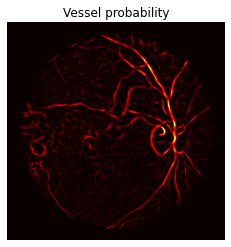

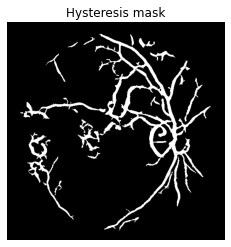

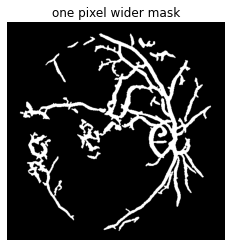

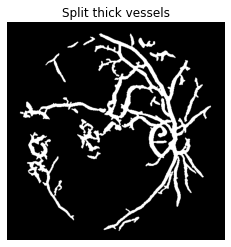

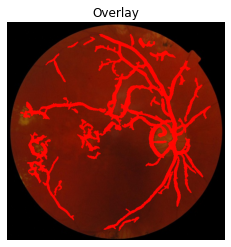

In [3]:
# RUN (single image)
img_path = r"C:\Users\shake\Documents\computational biology course\final_project\retinal-graphs-compBio\data\messidor-2\IM003360.JPG"
rgb = imread_rgb(img_path)

fov, radius = compute_fov_and_radius(rgb)
fov_in = inner_fov_mask(fov, radius)

# Preprocessed green image (THIS is your "gray")
I = preprocess_green(rgb, fov_in, radius)

# Vessel probability
V = vessel_prob_map(I, fov_in)
plt.imshow(V, cmap="hot"); plt.title("Vessel probability"); plt.axis("off"); plt.show()

# Hysteresis
lo, hi = pick_hi_lo_by_area(V, fov, seed_frac=0.06, cand_frac=0.20)
mask = hysteresis_segment(V, fov_in, hi=0.20, lo=0.04)
plt.imshow(mask, cmap="gray"); plt.title("Hysteresis mask"); plt.axis("off"); plt.show()
mask=thicken_by_one_pixel(mask)
plt.imshow(mask, cmap="gray"); plt.title("one pixel wider mask"); plt.axis("off"); plt.show()

# Split thick merged vessels
mask_split = split_thick(mask)
plt.imshow(mask_split, cmap="gray"); plt.title("Split thick vessels"); plt.axis("off"); plt.show()

# Light cleanup
mask_final = morphology.remove_small_objects(mask_split, 8)
mask_final &= fov_in

# Overlay
overlay = rgb.astype(np.float32) / 255.0
overlay[mask_final, 0] = 1.0
overlay[mask_final, 1] *= 0.3
overlay[mask_final, 2] *= 0.3

plt.imshow(overlay); plt.title("Overlay"); plt.axis("off"); plt.show()


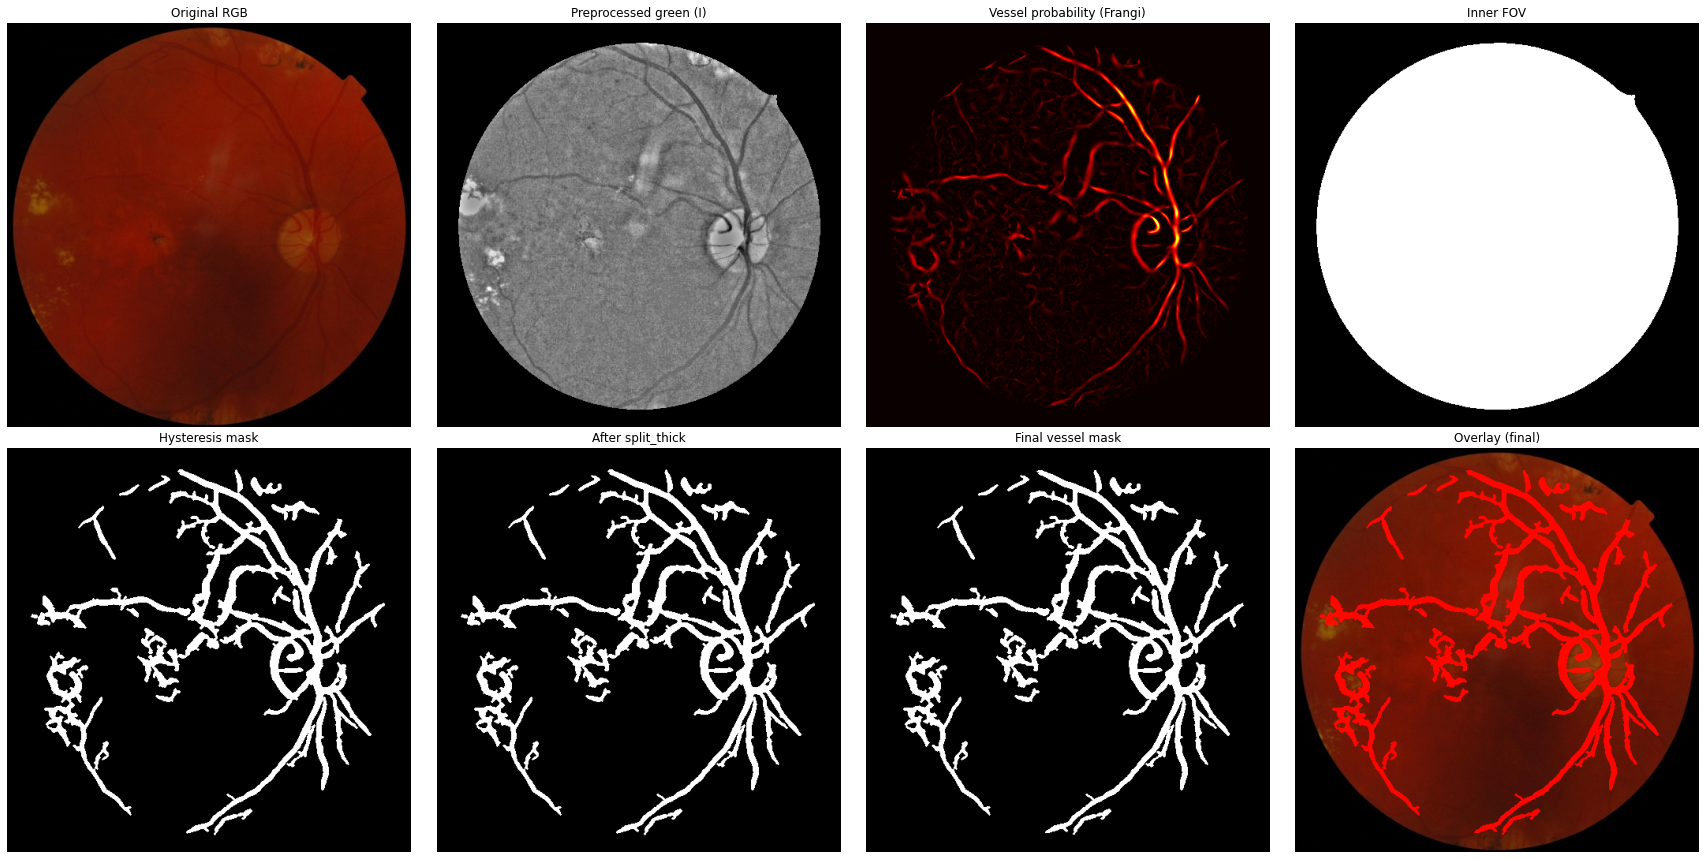

In [4]:
show_pipeline(rgb, I, V, mask, mask_split, mask_final, fov_in)

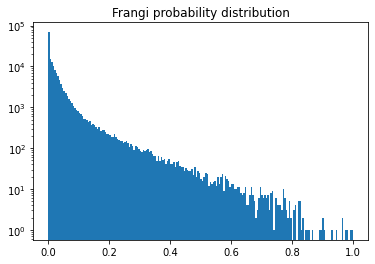

In [5]:
plt.hist(V[fov_in].ravel(), bins=200)
plt.yscale("log")
plt.title("Frangi probability distribution")
plt.show()

Saved results to: results_final\IM003360


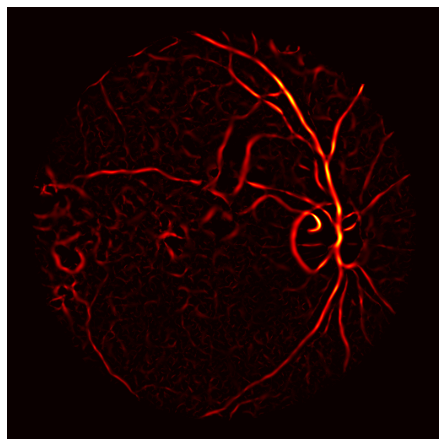

In [6]:

# -------------------------
# Save results (named by image)
# -------------------------
img_name = os.path.splitext(os.path.basename(img_path))[0]
out_dir = os.path.join("results_final", img_name)
os.makedirs(out_dir, exist_ok=True)

# 1) Save original RGB
imageio.imwrite(
    os.path.join(out_dir, f"{img_name}_original.png"),
    rgb
)

# 5) Save vessel probability map (Frangi) — FLOAT (recommended)
V_vis = np.clip(V, 0, 1)
plt.figure(figsize=(6, 6))
plt.imshow(V_vis, cmap="hot")
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig(
    os.path.join(out_dir, f"{img_name}_vessel_prob_hot.png"),
    dpi=200,
    bbox_inches="tight",
    pad_inches=0
)

# 2) Save final mask (0/255)
imageio.imwrite(
    os.path.join(out_dir, f"{img_name}_final_mask.png"),
    (mask_final.astype(np.uint8) * 255)
)

# 3) Save overlay image (red vessels on original)
overlay = rgb.copy().astype(np.uint8)
overlay[mask_final] = [255, 0, 0]
imageio.imwrite(
    os.path.join(out_dir, f"{img_name}_overlay.png"),
    overlay
)

# 4) Save combined summary (Original | Mask | Overlay)
fig = plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.imshow(rgb); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(mask_final, cmap="gray"); plt.title("Final mask"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(overlay); plt.title("Overlay (red=vessels)"); plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, f"{img_name}_summary.png"), dpi=200, bbox_inches="tight")
plt.close(fig)

# -------------------------
# OPTIONAL: debug saves (uncomment if you want)
# -------------------------
# imageio.imwrite(os.path.join(out_dir, f"{img_name}_fov_in.png"),
#                 (fov_in.astype(np.uint8) * 255))
#
# imageio.imwrite(os.path.join(out_dir, f"{img_name}_I_preprocessed.png"),
#                 (np.clip(I, 0, 1) * 255).astype(np.uint8))
#
# imageio.imwrite(os.path.join(out_dir, f"{img_name}_V_prob.png"),
#                 (np.clip(V, 0, 1) * 255).astype(np.uint8))
#
# imageio.imwrite(os.path.join(out_dir, f"{img_name}_mask_hysteresis.png"),
#                 (mask.astype(np.uint8) * 255))
#
# imageio.imwrite(os.path.join(out_dir, f"{img_name}_mask_split.png"),
#                 (mask_split.astype(np.uint8) * 255))
print(f"Saved results to: {out_dir}")